In [2]:
import torch
import numpy as np
from transformers import AutoModel
from huggingface_hub import login

In [3]:
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [4]:
from google.colab import drive
drive.mount('/content/drive')
path ="/content/drive/MyDrive/reve_eeg_dataset_epochs_piomegalo.npz"
data = np.load(path, allow_pickle=True)

print(data.files)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['X', 'y_cls', 'y_reg', 'subject_id', 'session_id', 'ch_names', 'trial_id']


In [5]:
X = data["X"]                # EEG epochs
y_cls = data["y_cls"]        # left/right class labels
y_reg = data["y_reg"]        # regression target
subject_id = data["subject_id"]
session_id = data["session_id"]
ch_names = data["ch_names"]
trial_id = data["trial_id"]
print("X shape:", X.shape, X.dtype)
print("y_cls shape:", y_cls.shape, y_cls.dtype)
print("y_reg shape:", y_reg.shape, y_reg.dtype)
print("subject_id shape:", subject_id.shape)
print("session_id shape:", session_id.shape)
print("ch_names shape:", ch_names.shape, ch_names.dtype)
print("trial_id shape:", trial_id.shape)
print("First channels:", ch_names[:5])

X shape: (4143, 64, 241) float32
y_cls shape: (4143,) int64
y_reg shape: (4143,) float32
subject_id shape: (4143,)
session_id shape: (4143,)
ch_names shape: (64,) object
trial_id shape: (4143,)
First channels: ['Fp1' 'AF7' 'AF3' 'F1' 'F3']


In [6]:
import numpy as np

# X shape: (N, C, T)
mean = X.mean(axis=2, keepdims=True)
std = X.std(axis=2, keepdims=True)


std = np.maximum(std, 1e-6)

X_norm = (X - mean) / std
X_norm = np.clip(X_norm, -15.0, 15.0).astype(np.float32)

print(X_norm.shape, X_norm.dtype)

(4143, 64, 241) float32


In [7]:
pos_bank = AutoModel.from_pretrained("brain-bzh/reve-positions", trust_remote_code=True)
model = AutoModel.from_pretrained("brain-bzh/reve-base", trust_remote_code=True)

Loading weights:   0%|          | 0/1 [00:00<?, ?it/s]

flash_attn not found, install it with `pip install flash_attn` if you want to use it


Loading weights:   0%|          | 0/140 [00:00<?, ?it/s]

In [8]:
for param in model.parameters():
    param.requires_grad = False

model.eval()

Reve(
  (transformer): TransformerBackbone(
    (layers): ModuleList(
      (0-21): 22 x ModuleList(
        (0): Attention(
          (norm): RMSNorm()
          (to_qkv): Linear(in_features=512, out_features=1536, bias=False)
          (to_out): Linear(in_features=512, out_features=512, bias=False)
          (attend): ClassicalAttention()
        )
        (1): FeedForward(
          (net): Sequential(
            (0): RMSNorm()
            (1): Linear(in_features=512, out_features=2722, bias=False)
            (2): GEGLU()
            (3): Linear(in_features=1361, out_features=512, bias=False)
          )
        )
      )
    )
  )
  (to_patch_embedding): Sequential(
    (0): Linear(in_features=200, out_features=512, bias=True)
  )
  (fourier4d): FourierEmb4D()
  (mlp4d): Sequential(
    (0): Linear(in_features=4, out_features=512, bias=False)
    (1): GELU(approximate='none')
    (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  )
  (ln): LayerNorm((512,), eps=1e-05, el

In [9]:
electrode_names = ch_names.tolist()
positions = pos_bank(electrode_names)
device = "cuda" if torch.cuda.is_available() else "cpu"


In [10]:
# =========================================================
# CELL 1 — EMBED FULL DATASET ONCE
# =========================================================
import numpy as np
import torch

def extract_reve_embeddings(X_array, positions, model, batch_size=32, device="cuda"):
    """
    X_array  : numpy array (N, C, T)
    positions: torch tensor (C, 3)
    returns  : torch tensor (N, D)
    """
    X_tensor = torch.tensor(X_array, dtype=torch.float32)
    all_embeddings = []

    model.eval()
    with torch.no_grad():
        for i in range(0, len(X_tensor), batch_size):
            xb = X_tensor[i:i + batch_size].to(device)                           # (B, C, T)
            posb = positions.unsqueeze(0).expand(xb.size(0), -1, -1).to(device) # (B, C, 3)

            layer_outputs = model(xb, posb, return_output=True)
            feats = layer_outputs[-1]

            if feats.ndim == 4:
                emb = feats.mean(dim=(1, 2))   # (B, D)
            elif feats.ndim == 3:
                emb = feats.mean(dim=1)   # (B, D)
            else:
                raise ValueError(f"Unexpected features shape: {feats.shape}")

            all_embeddings.append(emb.cpu())

    return torch.cat(all_embeddings, dim=0)


# --- Embed the full dataset once ---
X_emb_full = extract_reve_embeddings(X_norm, positions, model, batch_size=32, device=device)
y_cls_t = torch.tensor(y_cls, dtype=torch.long)

print("Full embeddings :", X_emb_full.shape)
print("Labels          :", y_cls_t.shape)
print("Subjects        :", np.unique(subject_id))

Full embeddings : torch.Size([4143, 512])
Labels          : torch.Size([4143])
Subjects        : [12 13 14 15 16 17 18 19 20 21 22 23]


In [11]:
import pandas as pd
import numpy as np
import os

# global log across the whole notebook session
try:
    all_results
except NameError:
    all_results = []

print(f"Global results already stored: {len(all_results)}")

Global results already stored: 0


In [12]:
import numpy as np
from sklearn.model_selection import train_test_split


SPLIT_SEED = 123

def make_fixed_subject_split(subject_id, split_seed=123):
    unique = np.unique(subject_id)

    # 8 train subjects, 4 remaining
    train_sub, temp_sub = train_test_split(
        unique,
        train_size=8,
        random_state=split_seed
    )

    # 1 val subject, 3 test subjects
    val_sub, test_sub = train_test_split(
        temp_sub,
        train_size=1,
        random_state=split_seed
    )

    train_mask = np.isin(subject_id, train_sub)
    val_mask   = np.isin(subject_id, val_sub)
    test_mask  = np.isin(subject_id, test_sub)

    split_info = {
        "split_seed": split_seed,
        "train_subjects": sorted(map(int, train_sub)),
        "val_subjects": sorted(map(int, val_sub)),
        "test_subjects": sorted(map(int, test_sub)),
        "train_mask": train_mask,
        "val_mask": val_mask,
        "test_mask": test_mask,
    }
    return split_info

fixed_split = make_fixed_subject_split(subject_id, split_seed=SPLIT_SEED)

print("Train subjects:", fixed_split["train_subjects"])
print("Val subjects:  ", fixed_split["val_subjects"])
print("Test subjects: ", fixed_split["test_subjects"])

print("Train samples:", fixed_split["train_mask"].sum())
print("Val samples:  ", fixed_split["val_mask"].sum())
print("Test samples: ", fixed_split["test_mask"].sum())

Train subjects: [13, 14, 15, 18, 19, 20, 22, 23]
Val subjects:   [16]
Test subjects:  [12, 17, 21]
Train samples: 2201
Val samples:   598
Test samples:  1344


In [13]:
import random
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support

SEEDS = [7, 21, 42, 84]
BATCH_SIZE = 64
N_EPOCHS = 30
HIDDEN_DIM = 128
DROPOUT = 0.4
LR = 1e-3
WEIGHT_DECAY = 1e-3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

#class MLPClassifier(nn.Module):
   # def __init__(self, input_dim):
    #    super().__init__()
     #   self.net = nn.Sequential(
      #      nn.Linear(input_dim, HIDDEN_DIM),
       #     nn.ReLU(),
        #    nn.Dropout(DROPOUT),
         #   nn.Linear(HIDDEN_DIM, 2)
        #)

    #def forward(self, x):
     #   return self.net(x)
class MLPClassifier(nn.Module):
  def __init__(self, input_dim):
    super().__init__()
    self.net = nn.Linear(input_dim, 2)

  def forward(self, x):
      return self.net(x)
def run_one_seed_fixed_split(seed, X_emb, y_cls_t, subject_id, fixed_split):
    print("\n" + "=" * 60)
    print(f"SEED {seed}")
    print("=" * 60)

    set_seed(seed)

    train_mask = fixed_split["train_mask"]
    val_mask   = fixed_split["val_mask"]
    test_mask  = fixed_split["test_mask"]

    print("Train subjects:", fixed_split["train_subjects"])
    print("Val subjects:  ", fixed_split["val_subjects"])
    print("Test subjects: ", fixed_split["test_subjects"])

    train_emb = X_emb[train_mask]
    val_emb   = X_emb[val_mask]
    test_emb  = X_emb[test_mask]

    y_train = y_cls_t[train_mask]
    y_val   = y_cls_t[val_mask]
    y_test  = y_cls_t[test_mask]

    print("Train:", tuple(train_emb.shape), tuple(y_train.shape))
    print("Val:  ", tuple(val_emb.shape), tuple(y_val.shape))
    print("Test: ", tuple(test_emb.shape), tuple(y_test.shape))

    train_loader = DataLoader(TensorDataset(train_emb, y_train), batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(TensorDataset(val_emb, y_val), batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(TensorDataset(test_emb, y_test), batch_size=BATCH_SIZE, shuffle=False)

    clf = MLPClassifier(train_emb.shape[1]).to(DEVICE)
    optimizer = torch.optim.AdamW(clf.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    best_val_acc = 0.0
    best_state = None

    for epoch in range(N_EPOCHS):
        clf.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()
            logits = clf(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * xb.size(0)
            train_correct += (logits.argmax(1) == yb).sum().item()
            train_total += yb.size(0)

        train_loss /= train_total
        train_acc = train_correct / train_total

        clf.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = clf(xb)
                loss = criterion(logits, yb)

                val_loss += loss.item() * xb.size(0)
                val_correct += (logits.argmax(1) == yb).sum().item()
                val_total += yb.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in clf.state_dict().items()}

        print(
            f"  Epoch {epoch+1:02d} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
        )

    clf.load_state_dict(best_state)
    clf.to(DEVICE)
    clf.eval()

    preds_all, true_all = [], []

    with torch.no_grad():
        for xb, yb in test_loader:
            logits = clf(xb.to(DEVICE))
            preds_all.extend(logits.argmax(1).cpu().numpy())
            true_all.extend(yb.numpy())

    test_acc = accuracy_score(true_all, preds_all)
    precision, recall, f1, _ = precision_recall_fscore_support(
        true_all, preds_all, average="binary"
    )

    print(f"\n  TEST ACC: {test_acc:.4f}")
    print(classification_report(true_all, preds_all, digits=4))

    return {
        "seed": seed,
        "split_seed": fixed_split["split_seed"],
        "train_subjects": fixed_split["train_subjects"],
        "val_subjects": fixed_split["val_subjects"],
        "test_subjects": fixed_split["test_subjects"],
        "best_val_loss": float(best_val_loss),
        "best_val_acc": float(best_val_acc),
        "test_acc": float(test_acc),
        "test_precision": float(precision),
        "test_recall": float(recall),
        "test_f1": float(f1),
        "n_train": int(train_mask.sum()),
        "n_val": int(val_mask.sum()),
        "n_test": int(test_mask.sum()),"hidden_dim": HIDDEN_DIM,
        "dropout": DROPOUT,
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
        "epochs": N_EPOCHS,
        "notes": "frozen REVE, pooled embeddings mean, 1-layer MLP"
    }

In [14]:
EXPERIMENT_NAME = "reve_frozen_lastlayer_mlp_dropout04"
WINDOW = "-1.2_0.0"
EMBEDDING_TYPE = "last_mean_pooling"

current_results = []

for seed in SEEDS:
    result = run_one_seed_fixed_split(seed, X_emb_full, y_cls_t, subject_id,fixed_split=fixed_split)
    result["experiment_name"] = EXPERIMENT_NAME
    result["embedding_type"] = EMBEDDING_TYPE
    result["window"] = WINDOW

    all_results.append(result)       # keep everything
    current_results.append(result)   # only this experiment

print("\n" + "="*60)
print(f"RESULTS: {EXPERIMENT_NAME}")
print("="*60)

for r in current_results:
    print(f"  Seed {r['seed']}: {r['test_acc']:.4f}")

accs = [r["test_acc"] for r in current_results]
print(f"\n  Mean : {np.mean(accs):.4f}")
print(f"  Std  : {np.std(accs):.4f}")


SEED 7
Train subjects: [13, 14, 15, 18, 19, 20, 22, 23]
Val subjects:   [16]
Test subjects:  [12, 17, 21]
Train: (2201, 512) (2201,)
Val:   (598, 512) (598,)
Test:  (1344, 512) (1344,)
  Epoch 01 | train_loss=0.8545 | train_acc=0.5066 | val_loss=0.6968 | val_acc=0.5217
  Epoch 02 | train_loss=0.7019 | train_acc=0.5298 | val_loss=0.7210 | val_acc=0.4967
  Epoch 03 | train_loss=0.7149 | train_acc=0.5234 | val_loss=0.6970 | val_acc=0.4983
  Epoch 04 | train_loss=0.6924 | train_acc=0.5552 | val_loss=0.7049 | val_acc=0.4916
  Epoch 05 | train_loss=0.6801 | train_acc=0.5602 | val_loss=0.7086 | val_acc=0.5067
  Epoch 06 | train_loss=0.6808 | train_acc=0.5725 | val_loss=0.7029 | val_acc=0.4900
  Epoch 07 | train_loss=0.6825 | train_acc=0.5670 | val_loss=0.7270 | val_acc=0.5334
  Epoch 08 | train_loss=0.6804 | train_acc=0.5570 | val_loss=0.7284 | val_acc=0.5334
  Epoch 09 | train_loss=0.6782 | train_acc=0.5725 | val_loss=0.7045 | val_acc=0.5301
  Epoch 10 | train_loss=0.6772 | train_acc=0.5670

#Validation


In [15]:
current_df = pd.DataFrame(current_results)
all_df = pd.DataFrame(all_results)

print("Current experiment:")
display(current_df)

print("\nAll experiments so far:")
display(all_df.tail(20))

Current experiment:


,seed,split_seed,train_subjects,val_subjects,test_subjects,best_val_loss,best_val_acc,test_acc,test_precision,test_recall,...,n_test,hidden_dim,dropout,lr,weight_decay,epochs,notes,experiment_name,embedding_type,window
0,7,123,"[13, 14, 15, 18, 19, 20, 22, 23]",[16],"[12, 17, 21]",0.696821,0.521739,0.520833,0.520349,0.782799,...,1344,128,0.4,0.001,0.001,30,"frozen REVE, pooled embeddings mean, 1-layer MLP",reve_frozen_lastlayer_mlp_dropout04,last_mean_pooling,-1.2_0.0
1,21,123,"[13, 14, 15, 18, 19, 20, 22, 23]",[16],"[12, 17, 21]",0.698757,0.545151,0.532738,0.534198,0.660350,...,1344,128,0.4,0.001,0.001,30,"frozen REVE, pooled embeddings mean, 1-layer MLP",reve_frozen_lastlayer_mlp_dropout04,last_mean_pooling,-1.2_0.0
2,42,123,"[13, 14, 15, 18, 19, 20, 22, 23]",[16],"[12, 17, 21]",0.691408,0.541806,0.526786,0.523321,0.817784,...,1344,128,0.4,0.001,0.001,30,"frozen REVE, pooled embeddings mean, 1-layer MLP",reve_frozen_lastlayer_mlp_dropout04,last_mean_pooling,-1.2_0.0
3,84,123,"[13, 14, 15, 18, 19, 20, 22, 23]",[16],"[12, 17, 21]",0.690947,0.528428,0.529762,0.537815,0.559767,...,1344,128,0.4,0.001,0.001,30,"frozen REVE, pooled embeddings mean, 1-layer MLP",reve_frozen_lastlayer_mlp_dropout04,last_mean_pooling,-1.2_0.0



All experiments so far:


,seed,split_seed,train_subjects,val_subjects,test_subjects,best_val_loss,best_val_acc,test_acc,test_precision,test_recall,...,n_test,hidden_dim,dropout,lr,weight_decay,epochs,notes,experiment_name,embedding_type,window
0,7,123,"[13, 14, 15, 18, 19, 20, 22, 23]",[16],"[12, 17, 21]",0.696821,0.521739,0.520833,0.520349,0.782799,...,1344,128,0.4,0.001,0.001,30,"frozen REVE, pooled embeddings mean, 1-layer MLP",reve_frozen_lastlayer_mlp_dropout04,last_mean_pooling,-1.2_0.0
1,21,123,"[13, 14, 15, 18, 19, 20, 22, 23]",[16],"[12, 17, 21]",0.698757,0.545151,0.532738,0.534198,0.660350,...,1344,128,0.4,0.001,0.001,30,"frozen REVE, pooled embeddings mean, 1-layer MLP",reve_frozen_lastlayer_mlp_dropout04,last_mean_pooling,-1.2_0.0
2,42,123,"[13, 14, 15, 18, 19, 20, 22, 23]",[16],"[12, 17, 21]",0.691408,0.541806,0.526786,0.523321,0.817784,...,1344,128,0.4,0.001,0.001,30,"frozen REVE, pooled embeddings mean, 1-layer MLP",reve_frozen_lastlayer_mlp_dropout04,last_mean_pooling,-1.2_0.0
3,84,123,"[13, 14, 15, 18, 19, 20, 22, 23]",[16],"[12, 17, 21]",0.690947,0.528428,0.529762,0.537815,0.559767,...,1344,128,0.4,0.001,0.001,30,"frozen REVE, pooled embeddings mean, 1-layer MLP",reve_frozen_lastlayer_mlp_dropout04,last_mean_pooling,-1.2_0.0


In [ ]:
save_dir = "/content/drive/MyDrive/reve_results"
os.makedirs(save_dir, exist_ok=True)

current_df.to_csv(f"{save_dir}/{EXPERIMENT_NAME}_results.csv", index=False)
current_df.to_json(f"{save_dir}/{EXPERIMENT_NAME}_results.json", orient="records", indent=2)

all_df.to_csv(f"{save_dir}/all_results_log.csv", index=False)
all_df.to_json(f"{save_dir}/all_results_log.json", orient="records", indent=2)

print("Saved to:", save_dir)

Saved to: /content/drive/MyDrive/reve_results


In [ ]:
# all_df = pd.DataFrame(all_results)

# summary_df = (
    # all_df
    # .agg(["count", "mean", "std", "min", "max"])
    # .reset_index()
    # .sort_values("mean", ascending=False)
# )

# summary_df

TypeError: complex() first argument must be a string or a number, not 'list'

In [ ]:
print("Train:", np.unique(y_cls[fixed_split["train_mask"]], return_counts=True))
print("Val:  ", np.unique(y_cls[fixed_split["val_mask"]], return_counts=True))
print("Test: ", np.unique(y_cls[fixed_split["test_mask"]], return_counts=True))

Train: (array([0, 1]), array([1096, 1061]))
Val:   (array([0, 1]), array([283, 333]))
Test:  (array([0, 1]), array([677, 715]))


#T-SNE for embedded X

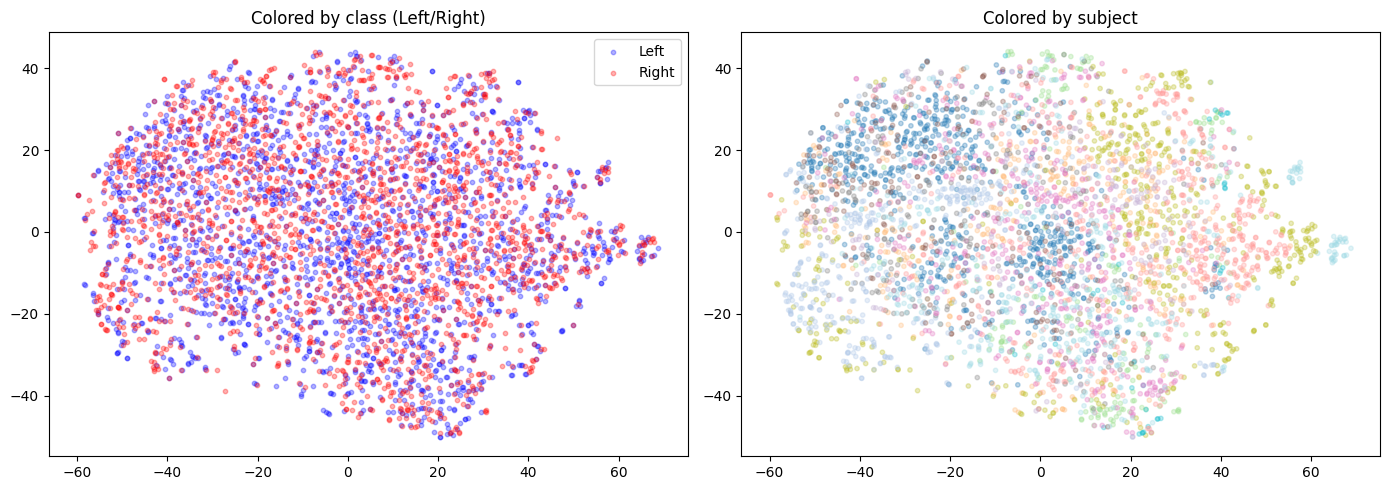

In [16]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
X_emb_full = PCA(n_components=50).fit_transform(X_emb_full)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(X_emb_full)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Color by class
axes[0].scatter(X_2d[y_cls==0, 0], X_2d[y_cls==0, 1], alpha=0.3, c='blue', s=10, label='Left')
axes[0].scatter(X_2d[y_cls==1, 0], X_2d[y_cls==1, 1], alpha=0.3, c='red',  s=10, label='Right')
axes[0].legend()
axes[0].set_title("Colored by class (Left/Right)")

# Color by subject
axes[1].scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.3,
                c=subject_id, cmap='tab20', s=10)
axes[1].set_title("Colored by subject")

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


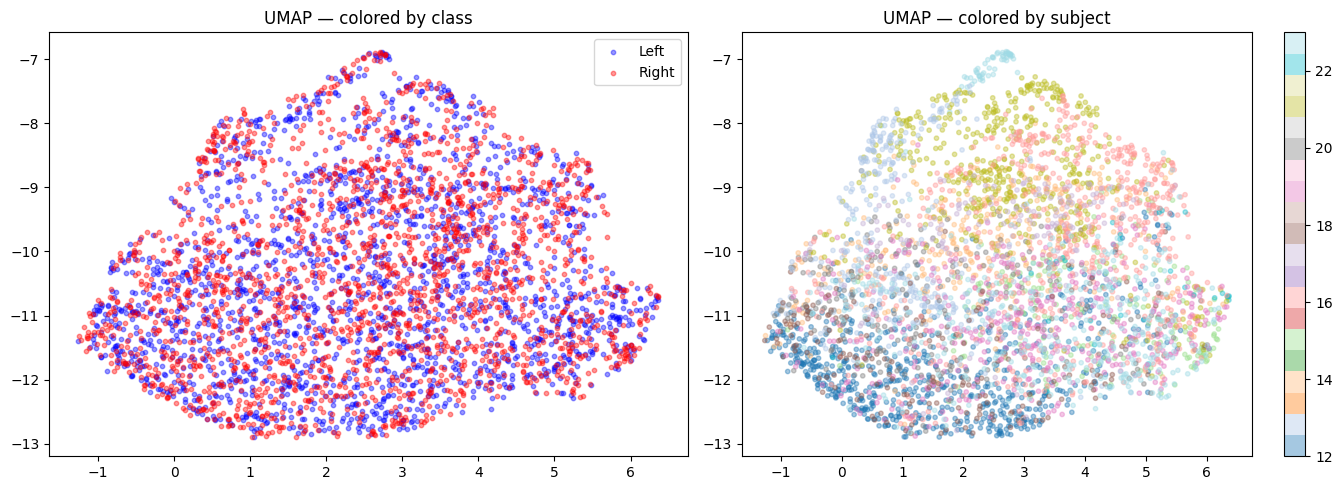

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from umap import UMAP


umap = UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
X_2d = umap.fit_transform(X_emb_full)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_2d[y_cls==0, 0], X_2d[y_cls==0, 1],
                alpha=0.4, c='blue', s=10, label='Left')
axes[0].scatter(X_2d[y_cls==1, 0], X_2d[y_cls==1, 1],
                alpha=0.4, c='red', s=10, label='Right')
axes[0].legend()
axes[0].set_title("UMAP — colored by class")

sc = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.4,
                     c=subject_id , cmap='tab20', s=10)
plt.colorbar(sc, ax=axes[1])
axes[1].set_title("UMAP — colored by subject")

plt.tight_layout()
plt.show()